# Structural characterization of networks

In this notebook, we will learn the functions needed to characterize both the microscopic and the macroscopic structure of networks. We will use the network of collaborations represented in the previous notebook
1. [Microscopic characterization of networks](#section1)
2. [Macroscopic characterization of networks](#section2)

## 1. Codes to set up the notebook for the simulation

### Code to grant access to the Google Drive folder

This command will be recurrent in all the notebooks and will allow us to set the working directory in our Google drive folder

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/CN_MHEDAS/Notebooks")

Mounted at /content/drive


### Code to import the needed modules/packages to run the notebook

In [1]:
import pandas as pd ## dataframes
import numpy as np ## Mathematical operations
import matplotlib.pyplot as plt ## Representation
from matplotlib import rcParams
from matplotlib import colors
import random as random
import networkx as nx ## Network tools

<a name='section2'></a>


## 2. Microscopic characterization of networks
<a id='section1'></a>


### In this section, we explain the functions of networkx to unravel the most central nodes according to different centrality measures

In [26]:
from scipy.io import mmread
import networkx as nx
a = mmread('../Datasets/ca-netscience.mtx')
G = nx.Graph(a)

FileNotFoundError: The source file does not exist: ../Datasets/ia-enron-only.mtx

First thing we will do is to set the color of nodes according to their degree, we will use the colormap 'Reds'. For other choices of colormaps, visit https://matplotlib.org/stable/users/explain/colors/colormaps.html

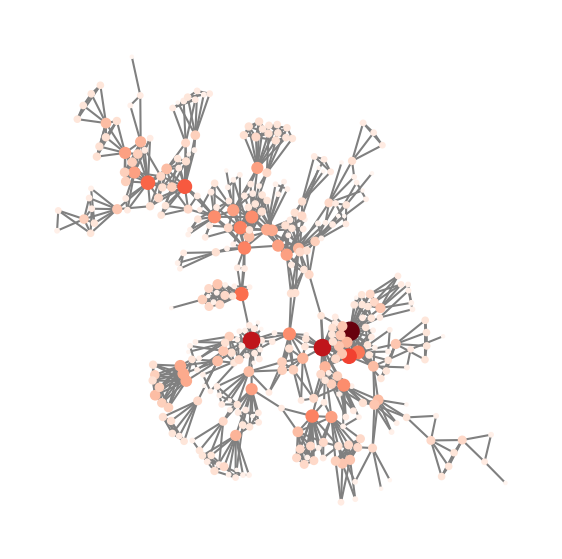

In [3]:
color_nodes=[G.degree(node) for node in G.nodes()]

sizes_nodes=[5*G.degree(node) for node in G.nodes()]
positions=nx.kamada_kawai_layout(G)
fig=plt.figure(figsize=(7,7))
nx.draw_networkx(G,node_size=sizes_nodes,pos=positions,edge_color='grey',node_color=color_nodes,width=1.5,with_labels=False,font_size=20,cmap='Reds')
## We recommend using a neutral color for the edges
plt.box(False)

Note that `G.degree()` is a function which should be called with the node of interest to get its degree

### Different centrality measures can be obtained by using networkx functions

In general, these functions return a `dict` object whose `keys` are nodes IDs and `values` corresponds to the centrality measure of interest

In [4]:
page_rank_centralities=nx.pagerank(G)
eigenvector_centralities=nx.eigenvector_centrality(G)
betweenness_centralities=nx.betweenness_centrality(G)
closeness_centralities=nx.closeness_centrality(G)

In [5]:
page_rank_centralities

{0: 0.0045385077906014305,
 1: 0.0013586183249172377,
 2: 0.0013586183249172377,
 3: 0.014519402022343916,
 4: 0.010772593302124673,
 5: 0.0015240158649455224,
 6: 0.004171223519263532,
 7: 0.007579072987585032,
 8: 0.0019910207819976845,
 9: 0.0032934133349874213,
 10: 0.001991020781997685,
 11: 0.001991020781997685,
 12: 0.0046517768704489515,
 13: 0.0018954181222809476,
 14: 0.006779393186293317,
 15: 0.008339646612352612,
 16: 0.005183048092165335,
 17: 0.004447216820226271,
 18: 0.0023923598162489505,
 19: 0.0015128492068169016,
 20: 0.0064494450974365,
 21: 0.0018281800022933647,
 22: 0.006278958663439732,
 23: 0.005766968062513821,
 24: 0.002089737817964688,
 25: 0.01616158887499995,
 26: 0.0020897378179646877,
 27: 0.0020897378179646877,
 28: 0.0008856058831511297,
 29: 0.004315885079047433,
 30: 0.002102657826108017,
 31: 0.00768273958262628,
 32: 0.0054046139255656805,
 33: 0.0021026578261080166,
 34: 0.0025431729418052234,
 35: 0.002088175107508579,
 36: 0.001168611353293068

Let's get the centrality indicators for node 1

In [6]:
### node denotes the node of interest

node=20
print(G.degree(node))
print('The PageRank centrality of node %s is: %.5f' %(node,page_rank_centralities[node]))
print('The eigevenctor centrality of node %s is: %.5f' %(node,eigenvector_centralities[node]))
print('The betweenness centrality of node %s is: %.5f' %(node,betweenness_centralities[node]))
print('The closeness centrality of node %s is: %.5f' %(node,closeness_centralities[node]))

12
The PageRank centrality of node 20 is: 0.00645
The eigevenctor centrality of node 20 is: 0.00215
The betweenness centrality of node 20 is: 0.04194
The closeness centrality of node 20 is: 0.21308


### Are centrality measures related?

To answer this question, we represent a scatter plot relating different centrality measures for the same node.

In [8]:
degree_centralities_values=[G.degree(node) for node in G.nodes()]
page_rank_centralities_values=[page_rank_centralities[node] for node in page_rank_centralities.keys()]
eigenvector_centralities_values=[eigenvector_centralities[node] for node in page_rank_centralities.keys()]
betweenness_centralities_values=[betweenness_centralities[node] for node in page_rank_centralities.keys()]
closeness_centralities_values=[closeness_centralities[node] for node in page_rank_centralities.keys()]

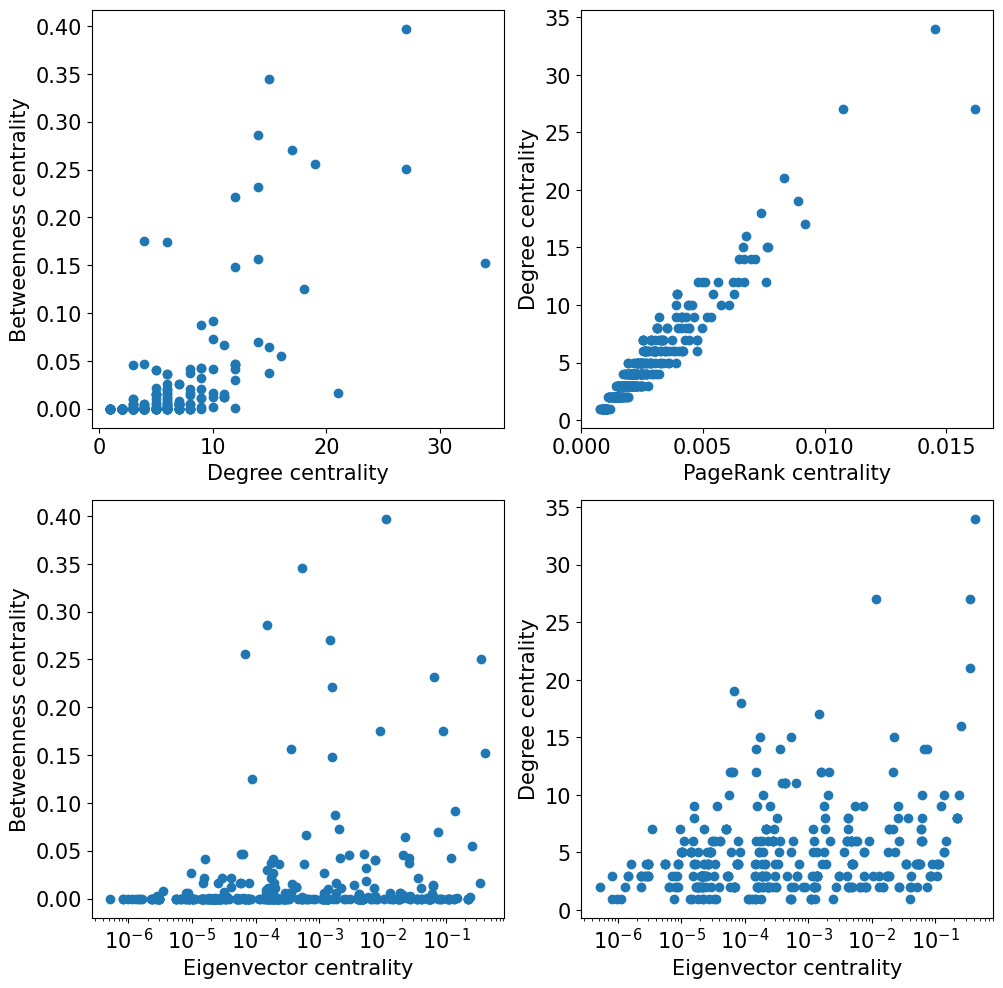

In [9]:
fig,ax=plt.subplots(2,2,figsize=(10,10))


ax[0][0].scatter(degree_centralities_values,betweenness_centralities_values)
ax[0][1].scatter(page_rank_centralities_values,degree_centralities_values)

ax[1][0].scatter(eigenvector_centralities_values,betweenness_centralities_values)
ax[1][1].scatter(eigenvector_centralities_values,degree_centralities_values)

ax[1][0].set_xscale('log')
ax[1][1].set_xscale('log')


ax[0][0].set_xlabel('Degree centrality',fontsize=15)
ax[0][0].set_ylabel('Betweenness centrality',fontsize=15)

ax[0][1].set_xlabel('PageRank centrality',fontsize=15)
ax[0][1].set_ylabel('Degree centrality',fontsize=15)


ax[1][0].set_xlabel('Eigenvector centrality',fontsize=15)
ax[1][0].set_ylabel('Betweenness centrality',fontsize=15)

ax[1][1].set_xlabel('Eigenvector centrality',fontsize=15)
ax[1][1].set_ylabel('Degree centrality',fontsize=15)

for row in range(2):
    for column in range(2):
        ax[row][column].tick_params(which='major',axis='both',labelsize=15)

fig.tight_layout()



We can also obtain some visual information about the different centrality measures by coloring each node according to them

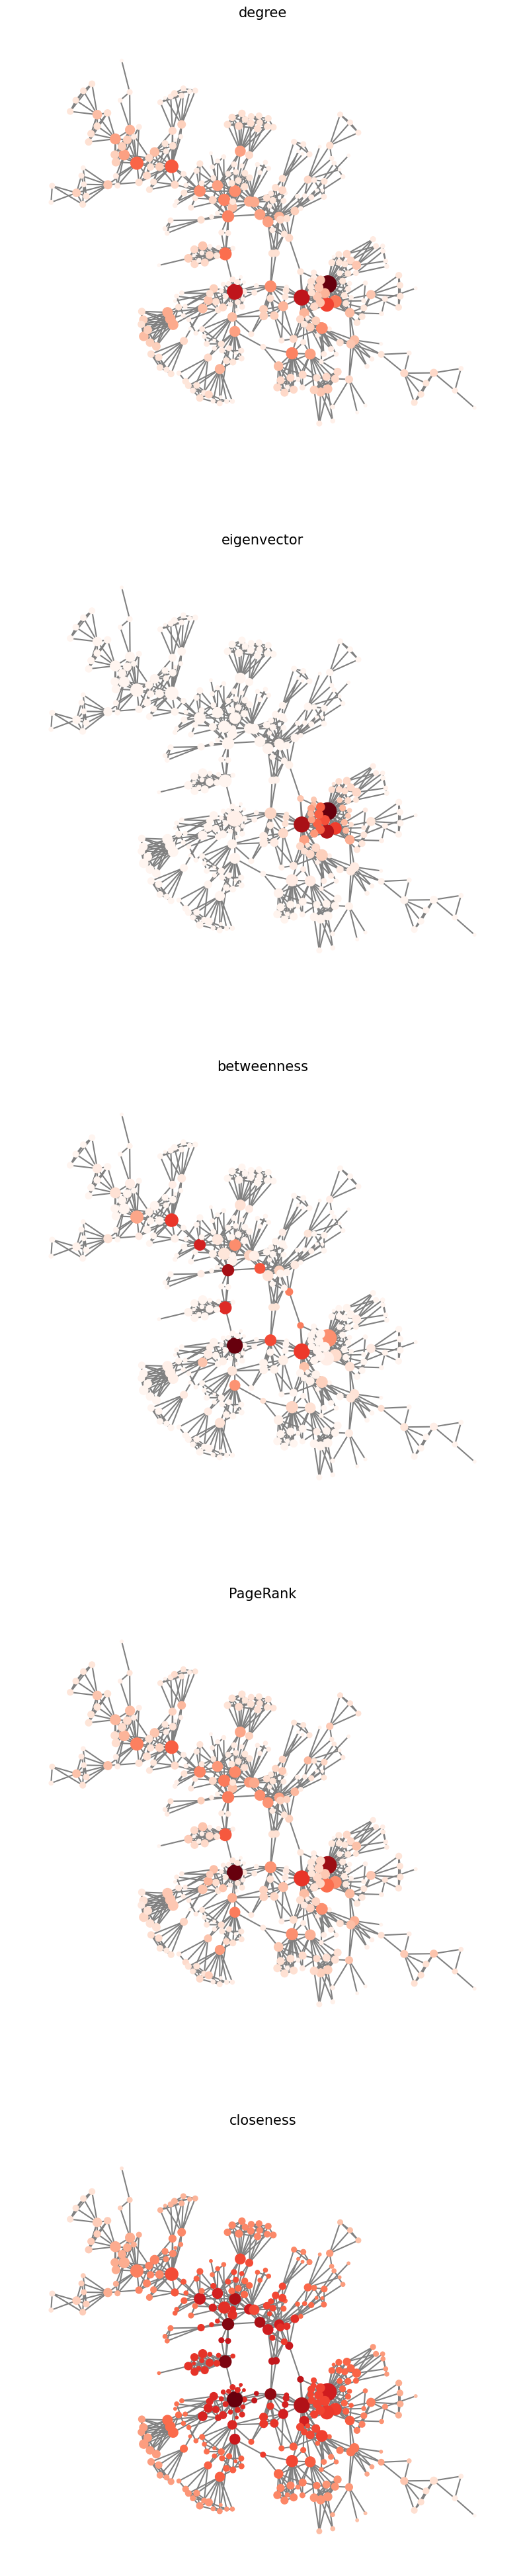

In [10]:
fig,ax=plt.subplots(5,1,figsize=(10,50))

sizes_nodes=[10*G.degree(node) for node in G.nodes()]
positions=nx.kamada_kawai_layout(G)
count_plot=0
for centrality in ['degree','eigenvector','betweenness','PageRank','closeness']:
    if centrality=='degree':
        color_nodes=[G.degree(node) for node in G.nodes()]
    if centrality=='eigenvector':
        color_nodes=[eigenvector_centralities[node] for node in G.nodes()]
    if centrality=='betweenness':
        color_nodes=[betweenness_centralities[node] for node in G.nodes()]
    if centrality=='PageRank':
        color_nodes=[page_rank_centralities[node] for node in G.nodes()]
    if centrality=='closeness':
        color_nodes=[closeness_centralities[node] for node in G.nodes()]

    nx.draw_networkx(G,node_size=sizes_nodes,pos=positions,edge_color='grey',node_color=color_nodes,width=1.5,with_labels=False,font_size=20,cmap='Reds',ax=ax[count_plot])
## We recommend using a neutral color for the edges
    ax[count_plot].axis('off')
    ax[count_plot].set_title(centrality,fontsize=15)
    count_plot+=1


Only PageRank and degree centrality seem to be related. Each centrality measure then encodes different information about the relevance of nodes in the network

### Finding the node with max degree

We can apply the `max` function to get the maximum node according to some criterion. In our case, we want to compare the nodes by their degree:

In [11]:
highest_degree_node = max(G.nodes, key=G.degree)
highest_degree_node

3

In [12]:
G.degree(3)

34

So we know that node `3` has 34 edges connected to it. Let's look at that calculation a little closer:

```python
max(G.nodes, key=G.degree)
```

We're telling the `max` function that we want the item from `G.nodes` that gives us the highest value when passed to the *key* function `G.degree`.

This construction works because `G.degree` is a function. 


Some other measures of centrality such as betweenness generate all of the nodes' centrality values at once and return a `dict`. In this case, we need an extra step:

### Finding the node with max betweenness


In [13]:
betweenness = nx.centrality.betweenness_centrality(G)
highest_betweenness_node = max(G.nodes, key=betweenness.get)
highest_betweenness_node

25

In [16]:
betweenness[highest_betweenness_node]

0.3971841813568121

Note that the following will throw an error:

In [17]:
max(G.nodes, key=betweenness)

TypeError: 'dict' object is not callable

This is because we need to provide a function to the `key` argument, but `betweenness` is a dict. To get around this, we use the dict's `get` method.

### Finding the node with max eigenvector centrality


In [19]:
eigenvector_centrality = nx.eigenvector_centrality(G)
max_node = max(eigenvector_centrality, key=eigenvector_centrality.get)
max_value = eigenvector_centrality[max_node]

print(f"Node with maximum eigenvector centrality: {max_node}")
print(f"Maximum eigenvector centrality value: {max_value}")

Node with maximum eigenvector centrality: 3
Maximum eigenvector centrality value: 0.41429869194859686


In [21]:
# Sort nodes by centrality in decreasing order
sorted_nodes = sorted(eigenvector_centrality, key=lambda node: eigenvector_centrality[node], reverse=True)

for node in sorted_nodes:
    print(f"Node: {node}, Eigenvector Centrality: {eigenvector_centrality[node]}")

Node: 3, Eigenvector Centrality: 0.41429869194859686
Node: 4, Eigenvector Centrality: 0.3562076098091821
Node: 15, Eigenvector Centrality: 0.3464498431757333
Node: 14, Eigenvector Centrality: 0.255742520988079
Node: 44, Eigenvector Centrality: 0.23695415610583817
Node: 45, Eigenvector Centrality: 0.2182443509837659
Node: 46, Eigenvector Centrality: 0.2182443509837659
Node: 175, Eigenvector Centrality: 0.2182443509837659
Node: 176, Eigenvector Centrality: 0.2182443509837659
Node: 249, Eigenvector Centrality: 0.14705016426957832
Node: 0, Eigenvector Centrality: 0.13911552224689064
Node: 312, Eigenvector Centrality: 0.13482071886308816
Node: 313, Eigenvector Centrality: 0.13482071886308816
Node: 12, Eigenvector Centrality: 0.12097798404454932
Node: 372, Eigenvector Centrality: 0.11588767102343438
Node: 13, Eigenvector Centrality: 0.10963067485617455
Node: 248, Eigenvector Centrality: 0.10765364730272699
Node: 322, Eigenvector Centrality: 0.1064163626498334
Node: 323, Eigenvector Centralit

In [22]:
sorted_nodes

[3,
 4,
 15,
 14,
 44,
 45,
 46,
 175,
 176,
 249,
 0,
 312,
 313,
 12,
 372,
 13,
 248,
 322,
 323,
 43,
 373,
 152,
 153,
 200,
 370,
 230,
 127,
 235,
 125,
 126,
 203,
 198,
 201,
 329,
 60,
 163,
 164,
 165,
 273,
 236,
 237,
 297,
 253,
 145,
 234,
 151,
 333,
 365,
 366,
 367,
 277,
 278,
 244,
 16,
 17,
 257,
 112,
 130,
 245,
 238,
 239,
 199,
 202,
 256,
 128,
 326,
 258,
 1,
 2,
 18,
 19,
 25,
 246,
 65,
 251,
 252,
 231,
 232,
 233,
 296,
 134,
 339,
 340,
 113,
 171,
 39,
 57,
 330,
 331,
 332,
 334,
 260,
 364,
 351,
 352,
 353,
 354,
 355,
 146,
 147,
 90,
 91,
 135,
 131,
 325,
 129,
 132,
 133,
 114,
 111,
 188,
 311,
 28,
 124,
 20,
 23,
 267,
 107,
 106,
 103,
 105,
 104,
 7,
 99,
 94,
 24,
 26,
 27,
 314,
 315,
 316,
 154,
 123,
 207,
 109,
 197,
 250,
 294,
 295,
 187,
 101,
 100,
 110,
 196,
 272,
 305,
 346,
 89,
 174,
 172,
 173,
 22,
 281,
 59,
 58,
 50,
 219,
 170,
 324,
 38,
 21,
 84,
 85,
 87,
 32,
 193,
 51,
 55,
 194,
 96,
 155,
 157,
 259,
 220,
 95,
 92,

### Clustering


In [24]:
node=20
clustering_value = nx.clustering(G, node)
print(f"Clustering coefficient for node {node}: {clustering_value}")

Clustering coefficient for node 20: 0.24242424242424243


In [25]:
clustering_coefficients = nx.clustering(G)
# Identify the node with the maximum clustering coefficient
max_clustering_node = max(clustering_coefficients, key=clustering_coefficients.get)
max_clustering_value = clustering_coefficients[max_clustering_node]

print(f"Node with maximum clustering coefficient: {max_clustering_node}")
print(f"Maximum clustering coefficient value: {max_clustering_value}")

Node with maximum clustering coefficient: 1
Maximum clustering coefficient value: 1.0


### Network of emails

Repeat the analysis for the network `ia-enron-only` encoding the exchange of emails among the employees of a company